# MVTec Dataset, VAE-GAN Checkpoint, and Inference

This notebook uses the current project functions to:

- load `configs/mvtec.yaml`
- load the MVTec dataset with `data.load_data`
- load the VAE-GAN checkpoint with `models.vaegan.load_model`
- run scoring with `modules.scoring.score_samples`
- fit a threshold with `modules.thresholding.fit_threshold`
- compute inference metrics with `modules.evaluation`
- plot samples, reconstructions, score distributions, and save inference results

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from data import load_data
from models.vaegan.loader import get_checkpoint_path, load_model
from modules.evaluation import prepare_binary_labels, ranking_metrics, threshold_metrics
from modules.scoring import score_samples
from modules.thresholding import fit_threshold
from utils import read_config, save_config_yaml

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

/Users/rashid/miniconda3/envs/pt/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Load Config

In [3]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "mvtec.yaml"
cfg = read_config(CONFIG_PATH)

requested_device = str(getattr(cfg, "device", "auto")).lower()
if requested_device == "auto":
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device(requested_device)

# The scoring module reads cfg.device directly.
cfg.device = str(device)

# Resolve project-relative checkpoint paths so this works whether Jupyter is
# launched from the repo root or from the notebooks/ folder.
checkpoint_root = Path(cfg.model.checkpoint_root)
if not checkpoint_root.is_absolute():
    cfg.model.checkpoint_root = str(PROJECT_ROOT / checkpoint_root)

checkpoint_path = get_checkpoint_path(cfg.model, cfg.data)

print(f"Dataset root: {cfg.data.dataset_root}")
print(f"Category:     {cfg.data.category}")
print(f"Device:       {cfg.device}")
print(f"Checkpoint:   {checkpoint_path}")
print(f"Exists:       {checkpoint_path.exists()}")

Dataset root: /Users/rashid/data/DS/AD/mvtec_anomaly_detection
Category:     hazelnut
Device:       cpu
Checkpoint:   /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/checkpoints/AD_MVTec/model_hazelnut_64.pt
Exists:       True


## Load Dataset

In [4]:
train_loader, test_loader, train_dataset, test_dataset = load_data(cfg)

dataset_summary = {
    "dataset": cfg.data.name,
    "category": cfg.data.category,
    "dataset_root": cfg.data.dataset_root,
    "train_images": len(train_dataset),
    "test_images": len(test_dataset),
    "train_classes": getattr(train_dataset, "classes", None),
    "test_classes": getattr(test_dataset, "classes", None),
    "test_class_to_idx": getattr(test_dataset, "class_to_idx", None),
    "batch_size": cfg.data.batch_size,
    "img_size": cfg.data.img_size,
}

dataset_summary

{'dataset': 'MVTec',
 'category': 'hazelnut',
 'dataset_root': '/Users/rashid/data/DS/AD/mvtec_anomaly_detection',
 'train_images': 391,
 'test_images': 110,
 'train_classes': ['good'],
 'test_classes': ['crack', 'cut', 'good', 'hole', 'print'],
 'test_class_to_idx': {'crack': 0, 'cut': 1, 'good': 2, 'hole': 3, 'print': 4},
 'batch_size': 16,
 'img_size': 128}

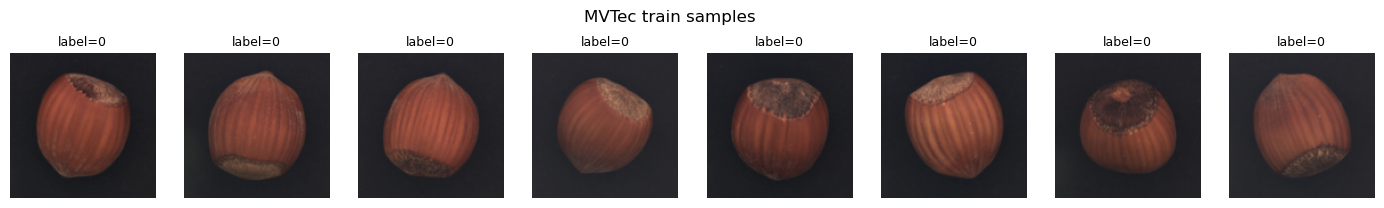

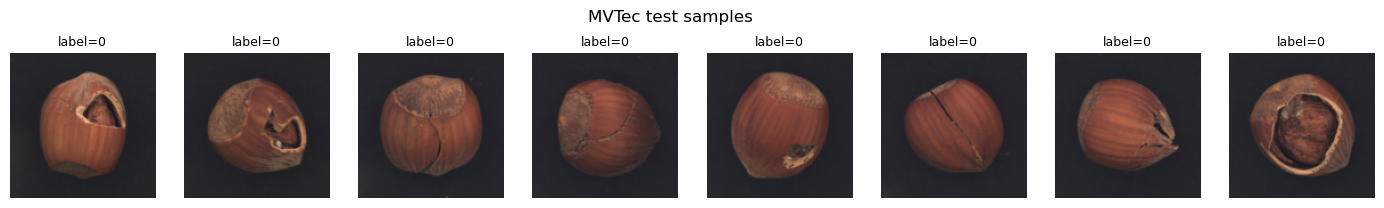

In [5]:
def show_batch(batch, title, max_images=8):
    images, labels = batch
    images = images[:max_images]
    labels = labels[:max_images]
    n = len(images)

    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.4))
    if n == 1:
        axes = [axes]
    for ax, image, label in zip(axes, images, labels):
        image = ((image.clamp(-1, 1) + 1) / 2).permute(1, 2, 0).numpy()
        ax.imshow(image)
        ax.set_title(f"label={int(label)}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.show()

show_batch(next(iter(train_loader)), "MVTec train samples")
show_batch(next(iter(test_loader)), "MVTec test samples")

## Load Checkpoint and Model

In [6]:
raw_checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
print("Checkpoint keys:")
print(list(raw_checkpoint.keys()))

loss_history = raw_checkpoint.get("loss_history")
if isinstance(loss_history, pd.DataFrame):
    print(f"Epochs in checkpoint loss history: {len(loss_history)}")
    display(loss_history.tail())
else:
    print(f"Loss history type: {type(loss_history)}")

Checkpoint keys:
['encoder_state_dict', 'decoder_state_dict', 'discriminator_state_dict', 'optimizer_enc_state_dict', 'optimizer_dec_state_dict', 'loss_history']
Epochs in checkpoint loss history: 1000


,recon_loss,kl_loss,gan_loss,beta_kl_loss,beta_gan_loss,vae_loss,disc_loss,annealing_lambda,dis_acc,dis_F1
995,0.000715,1.904287,0.900840,0.000190,0.000090,0.000996,0.612773,1.0,0.652344,0.638701
996,0.000755,1.942826,0.916243,0.000194,0.000092,0.001041,0.605326,1.0,0.677083,0.663043
997,0.000662,1.939002,0.914163,0.000194,0.000091,0.000948,0.572692,1.0,0.695312,0.699229
998,0.000771,1.939996,0.938077,0.000194,0.000094,0.001059,0.601626,1.0,0.665365,0.662286
999,0.000681,1.937680,0.909549,0.000194,0.000091,0.000966,0.619448,1.0,0.645833,0.632432


In [7]:
encoder, decoder, discriminator = load_model(cfg, device)
encoder.eval(); decoder.eval(); discriminator.eval()

print(type(encoder).__name__, type(decoder).__name__, type(discriminator).__name__)

Encoder Decoder Discriminator


## Reconstruction Preview

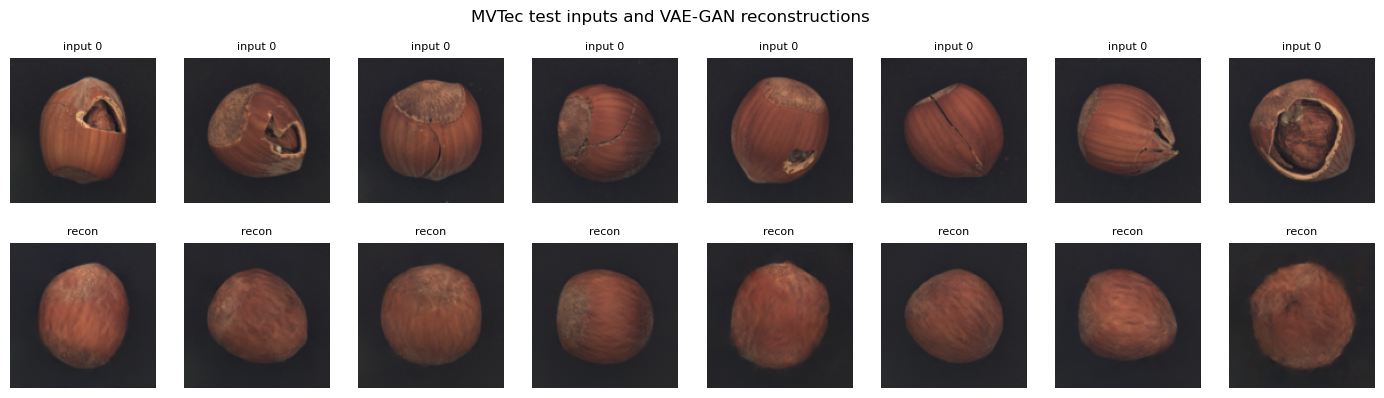

In [8]:
def denorm(image_tensor):
    return ((image_tensor.clamp(-1, 1) + 1) / 2).permute(1, 2, 0).detach().cpu().numpy()

images, labels = next(iter(test_loader))
images = images[:8].to(device)

with torch.inference_mode():
    mu, logvar = encoder(images)
    recon = decoder(mu)

fig, axes = plt.subplots(2, len(images), figsize=(2.2 * len(images), 4.4))
for i in range(len(images)):
    axes[0, i].imshow(denorm(images[i]))
    axes[0, i].set_title(f"input {int(labels[i])}", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(denorm(recon[i]))
    axes[1, i].set_title("recon", fontsize=8)
    axes[1, i].axis("off")
fig.suptitle("MVTec test inputs and VAE-GAN reconstructions")
plt.show()

## Run Inference Scores

In [9]:
train_scores, train_labels = score_samples(train_loader, encoder, decoder, discriminator, cfg)
test_scores, test_labels = score_samples(test_loader, encoder, decoder, discriminator, cfg)

threshold_model = fit_threshold(train_scores, cfg)
test_pred = threshold_model.predict(test_scores)
binary_test_labels = prepare_binary_labels(test_labels, getattr(test_dataset, "class_to_idx", None))

rank = ranking_metrics(test_scores.detach().cpu().numpy(), binary_test_labels)
thr = threshold_metrics(test_pred.detach().cpu().numpy(), binary_test_labels)
metrics = {**rank, **thr}

metrics

Scoring (l1): 100%|██████████| 7/7 [00:03<00:00,  2.33it/s]


{'auroc': 0.8478571428571429,
 'auprc': 0.9150892584201482,
 'precision': 0.6363636363636306,
 'recall': 0.9999999999999858,
 'f1': 0.777777777777294,
 'tp': 70,
 'tn': 0,
 'fn': 0,
 'fp': 40}

In [10]:
test_paths = [sample[0] for sample in getattr(test_dataset, "samples", [])]
idx_to_class = {idx: cls for cls, idx in getattr(test_dataset, "class_to_idx", {}).items()}

results_df = pd.DataFrame({
    "path": [str(path) for path in test_paths],
    "class_idx": test_labels.detach().cpu().numpy(),
    "class_name": [idx_to_class.get(int(idx), str(int(idx))) for idx in test_labels.detach().cpu().numpy()],
    "binary_label": binary_test_labels,
    "score": test_scores.detach().cpu().numpy(),
    "prediction": test_pred.detach().cpu().numpy(),
})

display(results_df.head())
display(results_df.groupby("class_name")[["score", "binary_label", "prediction"]].agg(["count", "mean"]))

,path,class_idx,class_name,binary_label,score,prediction
0,/Users/rashid/data/DS/AD/mvtec_anomaly_detecti...,0,crack,1,0.046083,1
1,/Users/rashid/data/DS/AD/mvtec_anomaly_detecti...,0,crack,1,0.039907,1
2,/Users/rashid/data/DS/AD/mvtec_anomaly_detecti...,0,crack,1,0.029950,1
3,/Users/rashid/data/DS/AD/mvtec_anomaly_detecti...,0,crack,1,0.024247,1
4,/Users/rashid/data/DS/AD/mvtec_anomaly_detecti...,0,crack,1,0.035601,1


score           binary_label      prediction     
           count      mean        count mean      count mean
class_name                                                  
crack         18  0.042998           18  1.0         18  1.0
cut           17  0.027971           17  1.0         17  1.0
good          40  0.025924           40  0.0         40  1.0
hole          18  0.030491           18  1.0         18  1.0
print         17  0.049069           17  1.0         17  1.0

## Plot Inference Results

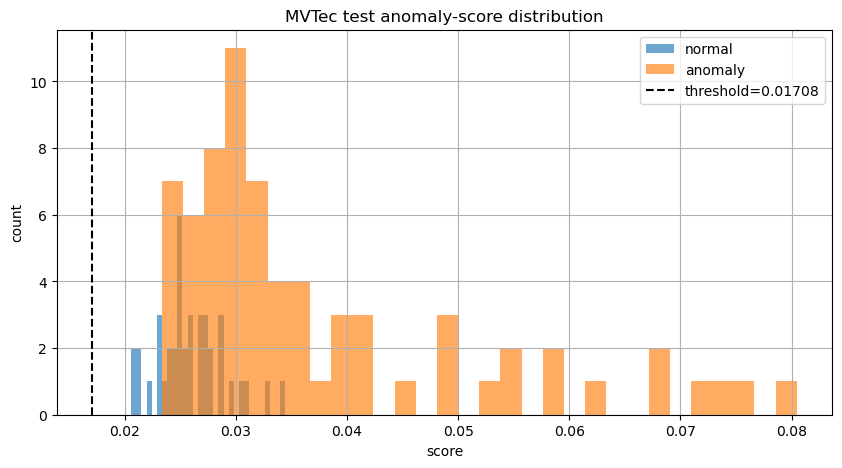

In [11]:
threshold_value = float(getattr(threshold_model, "threshold", np.nan))

fig, ax = plt.subplots(figsize=(10, 5))
for label_value, label_name in [(0, "normal"), (1, "anomaly")]:
    subset = results_df[results_df["binary_label"] == label_value]
    ax.hist(subset["score"], bins=30, alpha=0.65, label=label_name)
ax.axvline(threshold_value, color="black", linestyle="--", label=f"threshold={threshold_value:.5f}")
ax.set_title("MVTec test anomaly-score distribution")
ax.set_xlabel("score")
ax.set_ylabel("count")
ax.legend()
plt.show()

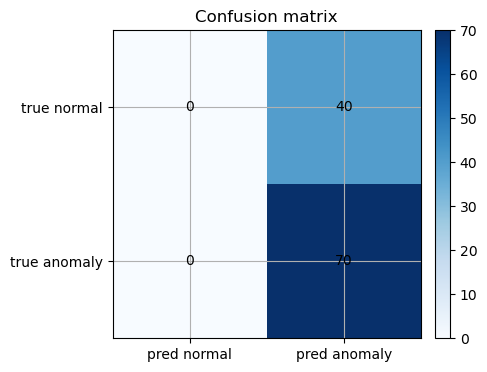

In [12]:
cm = np.array([
    [metrics["tn"], metrics["fp"]],
    [metrics["fn"], metrics["tp"]],
])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["pred normal", "pred anomaly"])
ax.set_yticks([0, 1], labels=["true normal", "true anomaly"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
ax.set_title("Confusion matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Save Notebook Outputs

In [13]:
output_dir = PROJECT_ROOT / "results" / "notebooks" / f"mvtec_{cfg.data.category}_inference"
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "inference_results.csv", index=False)
with open(output_dir / "metrics.json", "w", encoding="utf-8") as handle:
    json.dump(metrics, handle, indent=2)
with open(output_dir / "dataset_summary.json", "w", encoding="utf-8") as handle:
    json.dump(dataset_summary, handle, indent=2)
save_config_yaml(cfg, output_dir / "config_used.yaml")

print(output_dir)

/Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/results/notebooks/mvtec_hazelnut_inference
